In [61]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Q1

In [2]:
A = np.array([[1, 2],
            [4, 6],
            [7, 1]])

B = np.array([[0, 0], 
              [5, 5]])

In [8]:
A_exp = A[:, np.newaxis, :]
B_exp = B[np.newaxis, :, :]
print(A_exp.shape, B_exp.shape)

(3, 1, 2) (1, 2, 2)


In [4]:
diff = A_exp - B_exp
diff.shape

(3, 2, 2)

In [11]:
np.round(np.sqrt(np.sum(diff**2, axis=2)), 2)

array([[2.24, 5.  ],
       [7.21, 1.41],
       [7.07, 4.47]])

B1 is closer on average cuz avg B0 = (2 + 7 + 7)/3 = 5 for B1 = (5 + 1 + 4)/3 = 3

# Q2

In [12]:
p = [2, 1, -3]
q = [4, -2, 1]

In [31]:
res = 0
for i in range(3):
    res += p[i] * q[i]
print(res)

3


In [13]:
np.dot(p, q)

np.int64(3)

In [15]:
np.sum(np.multiply(p, q))

np.int64(3)

In [16]:
np.matmul(p, q)

np.int64(3)

In [34]:
_p = np.sqrt(np.sum(np.multiply(p, p)))
_q = np.sqrt(np.sum(np.multiply(q, q)))

cos_o = np.dot(p, q) / (_p * _q)

radian = np.arccos(cos_o) # radian
degrees = radian * (180/3.1415) # degrees
print(radian, degrees)

1.3949275767021716 79.92582008798054


They are more perpendicular

In [41]:
r = np.cross(p, q)
print(r)
np.dot(p, r)

[ -5 -14  -8]


np.int64(0)

# Q3

In [42]:
u = [3, -4]
v = [-6, 8]

In [46]:
u_mag = np.sqrt(np.sum(np.multiply(u, u)))
v_mag = np.sqrt(np.sum(np.multiply(v, v)))
print(u_mag, v_mag, v_mag / u_mag)

5.0 10.0 2.0


In [60]:
unit_u = np.divide(u, u_mag)
unit_v = np.divide(v, v_mag)

In [52]:
np.divide(v, u) # have equal proportions => parallel

array([-2., -2.])

# Q4

In [62]:
df = sns.load_dataset('mpg')

In [66]:
print(df.shape)
df.head()

(398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [80]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [81]:
df_clean = df.dropna()

In [84]:
df_clean.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


# Q5

In [89]:
df_clean[df_clean.mpg > 30].count()

mpg             83
cylinders       83
displacement    83
horsepower      83
weight          83
acceleration    83
model_year      83
origin          83
name            83
dtype: int64

In [98]:
df_clean = df_clean.sort_values(by="mpg", ascending=[False])

df_clean.head()[["name", "mpg", "cylinders", "origin"]]

,name,mpg,cylinders,origin
322,mazda glc,46.6,4,japan
329,honda civic 1500 gl,44.6,4,japan
325,vw rabbit c (diesel),44.3,4,europe
394,vw pickup,44.0,4,europe
326,vw dasher (diesel),43.4,4,europe


In [100]:
df_clean.groupby("origin")["mpg"].mean()

origin
europe    27.602941
japan     30.450633
usa       20.033469
Name: mpg, dtype: float64

Japan produce the most fuel-efficient cars on average

# Q6

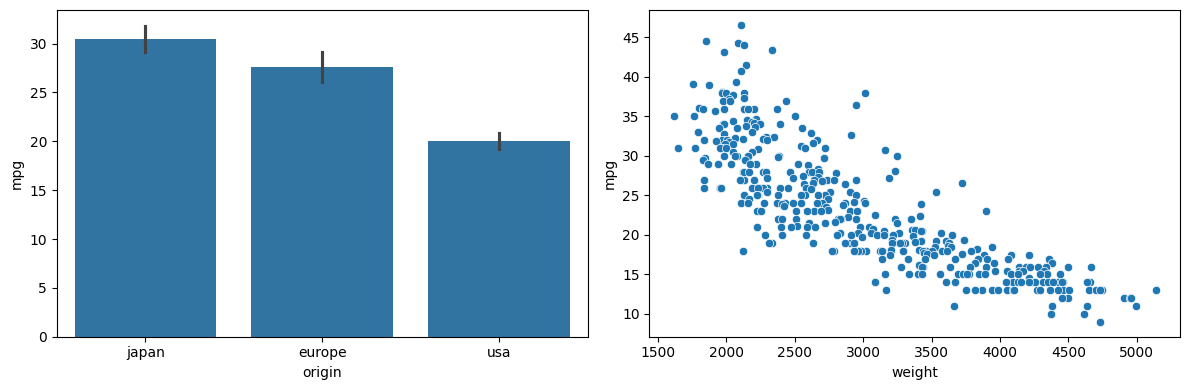

In [108]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df_clean, x="origin", y="mpg", ax=ax[0])

sns.scatterplot(data=df_clean, x="weight", y="mpg", ax=ax[1])

plt.tight_layout()
plt.show()

weight have negative correlation with mpg

# Q7

In [122]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [110]:
df_knn = load_wine()

In [116]:
print(df_knn.feature_names)
print(df_knn.target_names)
print(df_knn.data.shape)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']
(178, 13)


In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    df_knn.data,
    df_knn.target,
    test_size=0.25,
    random_state=42,
    stratify=df_knn.target
)

In [123]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
accuracy_score(y_test, pred)

0.7777777777777778

It classification problem, we need to define class of wine